# Simulated macro-financial variables

This exploratory notebook generates latent regimes, simulated macro-financial variables, and simulated charge-off rates. It does **not** train PtO, black-box, or DFL models.

## 1. Imports and setup

In [14]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, truncnorm

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

if "seaborn-v0_8-whitegrid" in plt.style.available:
    plt.style.use("seaborn-v0_8-whitegrid")
elif "seaborn-whitegrid" in plt.style.available:
    plt.style.use("seaborn-whitegrid")
else:
    plt.style.use("default")
pd.set_option("display.max_columns", 100)


def find_repo_root(start=None):
    """Find the repository root from either repo root, models/simulation, or a notebook subfolder."""
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "processed").exists() and (candidate / "models").exists():
            return candidate
    raise RuntimeError("Could not find repo root. Set REPO_ROOT manually in this cell.")


REPO_ROOT = find_repo_root()
MODELS_SRC = REPO_ROOT / "models" / "src"
if str(MODELS_SRC) not in sys.path:
    sys.path.insert(0, str(MODELS_SRC))

try:
    from capital_allocation_utils import CapitalConfig, annualised_pd_from_chargeoff, optimise_alpha_from_p, optimise_oracle_alpha
    HAS_OPTIMISATION_UTILS = True
except ImportError as exc:
    print(f"Could not import optimisation utilities: {exc}")
    HAS_OPTIMISATION_UTILS = False

print(f"Repo root: {REPO_ROOT}")
print(f"Optimisation utilities available: {HAS_OPTIMISATION_UTILS}")

Repo root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Optimisation utilities available: True


## 2. Load empirical macro-financial variables

The automatic discovery below looks in `data/processed`. If it chooses the wrong file, set `MACRO_CSV` and `CHARGEOFF_CSV` manually in the placeholder cell.

In [15]:

# Examples:
MACRO_CSV = REPO_ROOT / "data" / "processed" / "macro_panel_quarterly.csv"
CHARGEOFF_CSV = REPO_ROOT / "data" / "processed" / "fred_loan_return_aligned.csv"

In [16]:
processed_dir = REPO_ROOT / "data" / "processed"
csv_files = sorted(processed_dir.glob("*.csv"))

print("Available processed CSV files:")
for path in csv_files:
    print(f"- {path.relative_to(REPO_ROOT)}")

if MACRO_CSV is None:
    preferred_macro = processed_dir / "macro_panel_quarterly.csv"
    MACRO_CSV = preferred_macro if preferred_macro.exists() else next(
        path for path in csv_files if "macro" in path.name.lower()
    )

if CHARGEOFF_CSV is None:
    preferred_chargeoff = processed_dir / "fred_loan_return_aligned.csv"
    CHARGEOFF_CSV = preferred_chargeoff if preferred_chargeoff.exists() else next(
        path for path in csv_files if "charge" in path.name.lower() or "loan" in path.name.lower()
    )

print(f"\nUsing macro CSV: {Path(MACRO_CSV).relative_to(REPO_ROOT)}")
print(f"Using charge-off CSV: {Path(CHARGEOFF_CSV).relative_to(REPO_ROOT)}")

Available processed CSV files:
- data/processed/fred_loan_return_aligned.csv
- data/processed/macro_panel_quarter_start.csv
- data/processed/macro_panel_quarterly.csv
- data/processed/oracle_alpha.csv

Using macro CSV: data/processed/macro_panel_quarterly.csv
Using charge-off CSV: data/processed/fred_loan_return_aligned.csv


In [17]:
def load_time_series_csv(path, date_col="DATE"):
    df = pd.read_csv(path)
    if date_col not in df.columns:
        raise ValueError(f"{date_col!r} not found in {path}. Columns: {list(df.columns)}")
    df[date_col] = pd.to_datetime(df[date_col])
    return df.sort_values(date_col).reset_index(drop=True)


macro_df = load_time_series_csv(MACRO_CSV)
chargeoff_df = load_time_series_csv(CHARGEOFF_CSV)

# Keep the simulation timeline anchored on the empirical macro panel.
df = macro_df.copy()

display(df.head())
display(df.describe().T)

if "charge_off_rate" in chargeoff_df.columns:
    display(chargeoff_df[["DATE", "charge_off_rate"]].dropna().describe(include="all"))
else:
    print("No charge_off_rate column found in the discovered charge-off CSV.")

,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,corporate_bond_spread,senior_loan_officer_survey,excess_bond_premium
0,1990-06-30,1.5,5.333333,0.684295,0.736741,0.984464,0.423064,8.243333,0.103016,18.722063,1.638730,54.4,0.146990
1,1990-09-30,0.3,5.700000,0.386851,0.014248,1.712502,0.607283,8.160000,0.602540,25.195556,1.706190,46.7,-0.047302
2,1990-12-31,-3.6,6.133333,-1.560018,-0.804251,1.683668,-0.390403,7.743333,0.800161,26.113281,2.197419,54.2,0.266956
3,1991-03-31,-1.9,6.600000,-1.932577,0.306683,0.744790,0.833014,6.426667,0.987167,22.515833,2.186500,38.6,0.305454
4,1991-06-30,3.2,6.833333,0.526353,0.748178,0.591864,0.660265,5.863333,1.231406,17.147031,1.795937,20.0,0.162705


,count,mean,min,25%,50%,75%,max,std
DATE,144,2008-05-15 13:30:00,1990-06-30 00:00:00,1999-06-07 06:00:00,2008-05-15 12:00:00,2017-04-22 18:00:00,2026-03-31 00:00:00,NaN
real_gdp_growth,144.0,2.559722,-28.0,1.4,2.65,3.925,34.9,4.422294
unemployment_rate,144.0,5.667708,3.533333,4.333333,5.333333,6.608333,13.0,1.737437
industrial_production,144.0,0.342009,-13.437994,-0.063444,0.547605,1.064564,9.051291,1.79711
real_disposable_personal_income,144.0,0.638987,-7.941127,0.304946,0.667985,1.034683,11.578296,1.689404
cpi,144.0,0.65352,-2.316823,0.449815,0.70059,0.858804,2.324316,0.53608
house_price_index,144.0,1.015969,-3.198098,0.57318,1.02241,1.540598,6.248462,1.353091
federal_funds_rate,144.0,2.847245,0.06,0.318333,2.706667,5.185833,8.243333,2.301856
treasury_10y_2y_spread,144.0,1.012051,-0.766984,0.257148,0.863709,1.758642,2.800164,0.907135
vix,144.0,19.442831,10.307937,14.267969,17.468847,23.232001,58.604687,6.878609


,DATE,charge_off_rate
count,165,165.000000
mean,2005-07-01 11:29:27.272727,0.755455
min,1985-01-01 00:00:00,0.120000
25%,1995-04-01 00:00:00,0.310000
50%,2005-07-01 00:00:00,0.550000
75%,2015-10-01 00:00:00,1.200000
max,2026-01-01 00:00:00,2.570000
std,NaN,0.573369


## 3. Simulation and mixture configuration

The empirical mixture parameters are imported from `CapitalConfig`, which is the source used by the empirical PTO and black-box code.

In [18]:
if not HAS_OPTIMISATION_UTILS:
    raise ImportError("CapitalConfig and optimisation utilities are required for this simulation.")

LGD = 0.45
cap_cfg = CapitalConfig(lgd=LGD, leverage=10)

mixture_params = {
    "normal": {"mu": cap_cfg.mu_normal, "sigma": cap_cfg.sigma_normal},
    "stress": {"mu": cap_cfg.mu_stress, "sigma": cap_cfg.sigma_stress},
}

mixture_params_df = pd.DataFrame(mixture_params).T
mixture_params_df["negative_draw_probability"] = [
    norm.cdf(-row["mu"] / row["sigma"])
    for _, row in mixture_params_df.iterrows()
]

simulation_config = {
    "num_periods": 1000,
    "target_stress_frequency": 0.15,
    "beta_persistent": 0.45,
    "beta_leading": 0.35,
    "beta_regime": 0.60,
    "persistent_ar": 0.80,
    "persistent_regime_loading": 0.25,
    "persistent_noise_sd": 0.35,
    "leading_regime_loading": 0.20,
    "leading_persistent_loading": 0.30,
    "leading_noise_sd": 0.60,
    "rho_chargeoff": 0.70,
}

print("Empirical mixture parameters from CapitalConfig:")
display(mixture_params_df)
print("Simulation configuration:")
display(pd.Series(simulation_config))

Empirical mixture parameters from CapitalConfig:


,mu,sigma,negative_draw_probability
normal,0.0061,0.0042,0.073198
stress,0.0143,0.0067,0.016408


Simulation configuration:


num_periods                   1000.00
target_stress_frequency          0.15
beta_persistent                  0.45
beta_leading                     0.35
beta_regime                      0.60
persistent_ar                    0.80
persistent_regime_loading        0.25
persistent_noise_sd              0.35
leading_regime_loading           0.20
leading_persistent_loading       0.30
leading_noise_sd                 0.60
rho_chargeoff                    0.70
dtype: float64

## 4. Generate simulated macro-financial variables

Rows are forecasting examples. The variables in row `t` are predictors observed at time `t`; `sim_true_stress_probability`, `sim_regime`, `sim_charge_off_rate`, PDs, and oracle alpha are targets for `t+1`.

- `sim_current_regime`: the realised regime known at time `t`, used only as lagged state information.
- `sim_persistent_stress_indicator`: a persistent observed stress signal at time `t`.
- `sim_noisy_leading_indicator`: a noisy observed early-warning signal at time `t`.
- `sim_irrelevant_noise`: unrelated noise, excluded from the true stress-probability equation.

In [20]:
num_periods = simulation_config["num_periods"]
dates = pd.date_range(end="2026-03-31", periods=num_periods, freq="QE")


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def simulate_predictors_and_regimes(intercept, seed=SEED):
    """Simulate predictor rows at t and Bernoulli target regimes at t+1."""
    local_rng = np.random.default_rng(seed)
    current_regime = np.zeros(num_periods, dtype=int)
    next_regime = np.zeros(num_periods, dtype=int)
    persistent = np.zeros(num_periods)
    leading = np.zeros(num_periods)
    irrelevant = local_rng.normal(0.0, 1.0, size=num_periods)

    persistent_state = 0.0
    for t in range(num_periods):
        if t > 0:
            current_regime[t] = next_regime[t - 1]

        # Predictor variables are generated from information available at time t.
        persistent_state = (
            simulation_config["persistent_ar"] * persistent_state
            + simulation_config["persistent_regime_loading"] * current_regime[t]
            + local_rng.normal(0.0, simulation_config["persistent_noise_sd"])
        )
        persistent[t] = persistent_state
        leading[t] = (
            simulation_config["leading_regime_loading"] * current_regime[t]
            + simulation_config["leading_persistent_loading"] * persistent_state
            + local_rng.normal(0.0, simulation_config["leading_noise_sd"])
        )

        linear_score = (
            intercept
            + simulation_config["beta_persistent"] * persistent[t]
            + simulation_config["beta_leading"] * leading[t]
            + simulation_config["beta_regime"] * current_regime[t]
        )
        p_next = float(sigmoid(linear_score))
        next_regime[t] = int(local_rng.binomial(1, p_next))

    linear_score = (
        intercept
        + simulation_config["beta_persistent"] * persistent
        + simulation_config["beta_leading"] * leading
        + simulation_config["beta_regime"] * current_regime
    )
    p_true = sigmoid(linear_score)

    return pd.DataFrame({
        "DATE": dates,
        "sim_target_DATE": dates + pd.offsets.QuarterEnd(1),
        "sim_current_regime": current_regime,
        "sim_current_regime_label": np.where(current_regime == 1, "stress", "normal"),
        "sim_persistent_stress_indicator": persistent,
        "sim_noisy_leading_indicator": leading,
        "sim_irrelevant_noise": irrelevant,
        "sim_true_stress_probability": p_true,
        "sim_regime": next_regime,
        "sim_regime_label": np.where(next_regime == 1, "stress", "normal"),
    })


def calibrate_intercept(target_frequency):
    low, high = -8.0, 4.0
    for _ in range(35):
        mid = 0.5 * (low + high)
        candidate = simulate_predictors_and_regimes(mid, seed=SEED)
        realised_frequency = candidate["sim_regime"].mean()
        if realised_frequency < target_frequency:
            low = mid
        else:
            high = mid
    return 0.5 * (low + high)


stress_intercept = calibrate_intercept(simulation_config["target_stress_frequency"])
sim_df = simulate_predictors_and_regimes(stress_intercept, seed=SEED)
simulation_config["intercept"] = stress_intercept

sim_macro_cols = [
    "sim_persistent_stress_indicator",
    "sim_noisy_leading_indicator",
    "sim_irrelevant_noise",
]

print(f"Calibrated stress intercept: {stress_intercept:.4f}")
print(f"Target stress frequency: {simulation_config['target_stress_frequency']:.3f}")
print(f"Realised stress frequency: {sim_df['sim_regime'].mean():.3f}")
display(sim_df[["DATE", "sim_target_DATE", "sim_current_regime", *sim_macro_cols, "sim_true_stress_probability", "sim_regime"]].head())
display(sim_df[sim_macro_cols + ["sim_true_stress_probability"]].describe().T)

Calibrated stress intercept: -2.0144
Target stress frequency: 0.150
Realised stress frequency: 0.149


,DATE,sim_target_DATE,sim_current_regime,sim_persistent_stress_indicator,sim_noisy_leading_indicator,sim_irrelevant_noise,sim_true_stress_probability,sim_regime
0,1776-06-30,1776-09-30,0,-0.020749,-0.443797,0.304717,0.101648,0
1,1776-09-30,1776-12-31,0,0.205269,0.063377,-1.039984,0.130127,0
2,1776-12-31,1777-03-31,0,0.398743,-0.105282,0.750451,0.133334,0
3,1777-03-31,1777-06-30,0,0.451590,-0.605411,0.940565,0.116803,0
4,1777-06-30,1777-09-30,0,0.186011,-0.937254,-1.951035,0.094600,0


,count,mean,std,min,25%,50%,75%,max
sim_persistent_stress_indicator,1000.0,0.092158,0.607069,-2.031470,-0.309538,0.113521,0.512423,2.103976
sim_noisy_leading_indicator,1000.0,0.066130,0.660751,-1.949404,-0.370245,0.083772,0.506562,2.293133
sim_irrelevant_noise,1000.0,-0.028892,0.989217,-3.648413,-0.696313,0.006178,0.589887,3.178854
sim_true_stress_probability,1000.0,0.145661,0.067096,0.031975,0.097611,0.130719,0.171419,0.480506


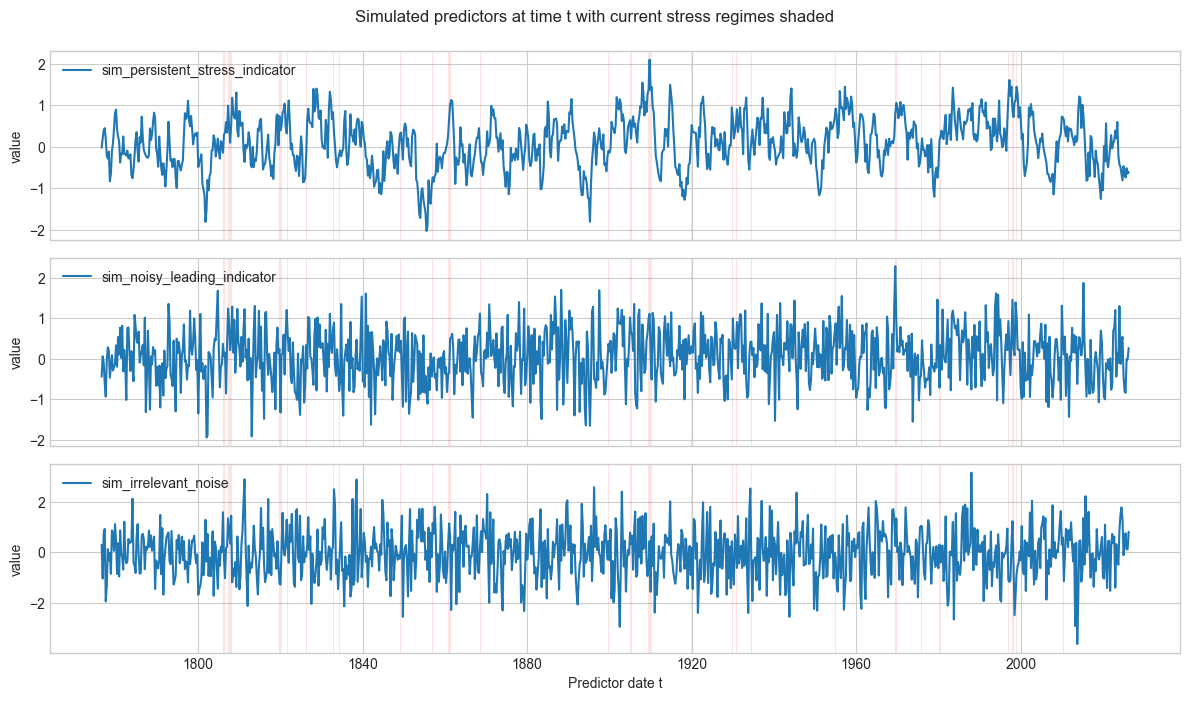

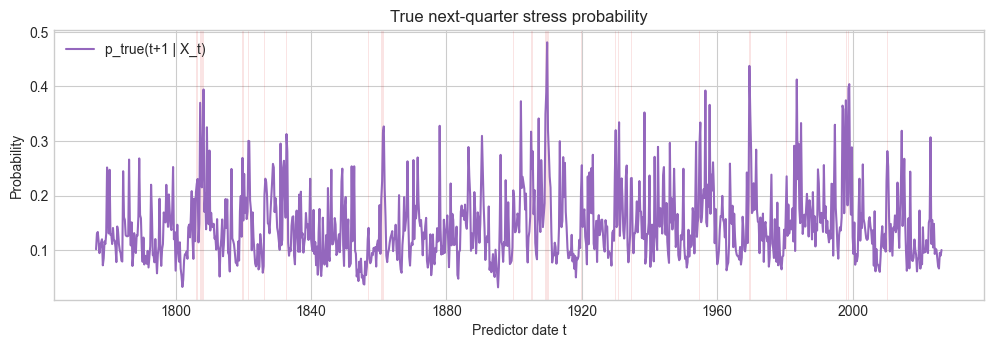

In [21]:
def shade_stress_periods(ax, dates, regimes, color="tab:red", alpha=0.12):
    dates = pd.Series(pd.to_datetime(dates)).reset_index(drop=True)
    regimes = pd.Series(regimes).reset_index(drop=True)
    in_stress = False
    start = None
    for i, is_stress in enumerate(regimes.eq(1)):
        if is_stress and not in_stress:
            start = dates.iloc[i]
            in_stress = True
        if in_stress and ((not is_stress) or i == len(regimes) - 1):
            end = dates.iloc[i] if is_stress else dates.iloc[max(i - 1, 0)]
            ax.axvspan(start, end, color=color, alpha=alpha, linewidth=0)
            in_stress = False


fig, axes = plt.subplots(len(sim_macro_cols), 1, figsize=(12, 7), sharex=True)
for ax, col in zip(axes, sim_macro_cols):
    ax.plot(sim_df["DATE"], sim_df[col], label=col)
    shade_stress_periods(ax, sim_df["DATE"], sim_df["sim_current_regime"])
    ax.set_ylabel("value")
    ax.legend(loc="upper left")
axes[-1].set_xlabel("Predictor date t")
fig.suptitle("Simulated predictors at time t with current stress regimes shaded", y=0.995)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(sim_df["DATE"], sim_df["sim_true_stress_probability"], color="tab:purple", label="p_true(t+1 | X_t)")
shade_stress_periods(ax, sim_df["DATE"], sim_df["sim_current_regime"])
ax.set_title("True next-quarter stress probability")
ax.set_ylabel("Probability")
ax.set_xlabel("Predictor date t")
ax.legend(loc="upper left")
plt.show()

## 5. Generate simulated charge-off rates

Realised target charge-offs are drawn from the same two-regime Gaussian mixture used by the empirical PTO and future DFL decision layer. If the empirical normal distribution has non-negligible probability below zero, sampling uses a zero-lower-bounded truncated normal rather than clipping.

In [22]:
NEGATIVE_VALUE_RESAMPLE_LIMIT = 10_000
rho_chargeoff = simulation_config["rho_chargeoff"]
innovation_sd = {
    "normal": cap_cfg.sigma_normal * np.sqrt(1.0 - rho_chargeoff**2),
    "stress": cap_cfg.sigma_stress * np.sqrt(1.0 - rho_chargeoff**2),
}

sim_df["sim_expected_charge_off_rate"] = (
    (1.0 - sim_df["sim_true_stress_probability"]) * cap_cfg.mu_normal
    + sim_df["sim_true_stress_probability"] * cap_cfg.mu_stress
)
sim_df["sim_alpha_from_true_probability"] = [
    optimise_alpha_from_p(float(p), cap_cfg)
    for p in sim_df["sim_true_stress_probability"]
]


def draw_persistent_chargeoffs(regimes, cfg=cap_cfg, rho=rho_chargeoff):
    """Draw c_{t+1} from a regime-dependent AR(1), resampling innovations if c <= 0."""
    regimes = np.asarray(regimes, dtype=int)
    chargeoffs = np.empty(len(regimes), dtype=float)
    resample_count = 0

    first_mu = cfg.mu_stress if regimes[0] == 1 else cfg.mu_normal
    first_sigma = cfg.sigma_stress if regimes[0] == 1 else cfg.sigma_normal
    first_innovation_sd = first_sigma * np.sqrt(1.0 - rho**2)
    first_value = first_mu + rng.normal(0.0, first_innovation_sd)
    attempts = 0
    while first_value <= 0.0:
        attempts += 1
        resample_count += 1
        if attempts > NEGATIVE_VALUE_RESAMPLE_LIMIT:
            raise RuntimeError("Too many negative charge-off redraws at t=0.")
        first_value = first_mu + rng.normal(0.0, first_innovation_sd)
    chargeoffs[0] = first_value

    for t in range(1, len(regimes)):
        prev_regime = regimes[t - 1]
        current_regime = regimes[t]
        prev_mu = cfg.mu_stress if prev_regime == 1 else cfg.mu_normal
        current_mu = cfg.mu_stress if current_regime == 1 else cfg.mu_normal
        current_sigma = cfg.sigma_stress if current_regime == 1 else cfg.sigma_normal
        current_innovation_sd = current_sigma * np.sqrt(1.0 - rho**2)

        attempts = 0
        while True:
            innovation = rng.normal(0.0, current_innovation_sd)
            candidate = current_mu + rho * (chargeoffs[t - 1] - prev_mu) + innovation
            if candidate > 0.0:
                chargeoffs[t] = candidate
                break
            attempts += 1
            resample_count += 1
            if attempts > NEGATIVE_VALUE_RESAMPLE_LIMIT:
                raise RuntimeError(f"Too many negative charge-off redraws at t={t}.")

    return chargeoffs, resample_count


sim_df["sim_charge_off_rate"], chargeoff_resample_count = draw_persistent_chargeoffs(sim_df["sim_regime"], cap_cfg, rho_chargeoff)
sim_df["sim_quarterly_pd"] = np.clip(sim_df["sim_charge_off_rate"] / cap_cfg.lgd, cap_cfg.pd_floor, cap_cfg.pd_cap)
sim_df["sim_annual_pd"] = annualised_pd_from_chargeoff(sim_df["sim_charge_off_rate"].to_numpy(), cap_cfg)
sim_df["sim_oracle_alpha"] = [optimise_oracle_alpha(float(c), cap_cfg) for c in sim_df["sim_charge_off_rate"]]

print(f"Charge-off AR(1) rho: {rho_chargeoff:.2f}")
print("Innovation standard deviations:")
display(pd.Series(innovation_sd))
print(f"Negative generated charge-off resamples: {chargeoff_resample_count}")
print("Empirical target mixture parameters and theoretical negative-draw probabilities:")
display(mixture_params_df)
print("Simulated charge-off moments by realised target regime:")
display(sim_df.groupby("sim_regime_label")["sim_charge_off_rate"].agg(["count", "mean", "std", "min", "max"]))

Charge-off AR(1) rho: 0.70
Innovation standard deviations:


normal    0.002999
stress    0.004785
dtype: float64

Negative generated charge-off resamples: 65
Empirical target mixture parameters and theoretical negative-draw probabilities:


,mu,sigma,negative_draw_probability
normal,0.0061,0.0042,0.073198
stress,0.0143,0.0067,0.016408


Simulated charge-off moments by realised target regime:


,count,mean,std,min,max
sim_regime_label,,,,,
normal,851,0.006652,0.003694,0.000022,0.020194
stress,149,0.014917,0.005314,0.001362,0.027213


## 6. Plot generated charge-offs and PDs

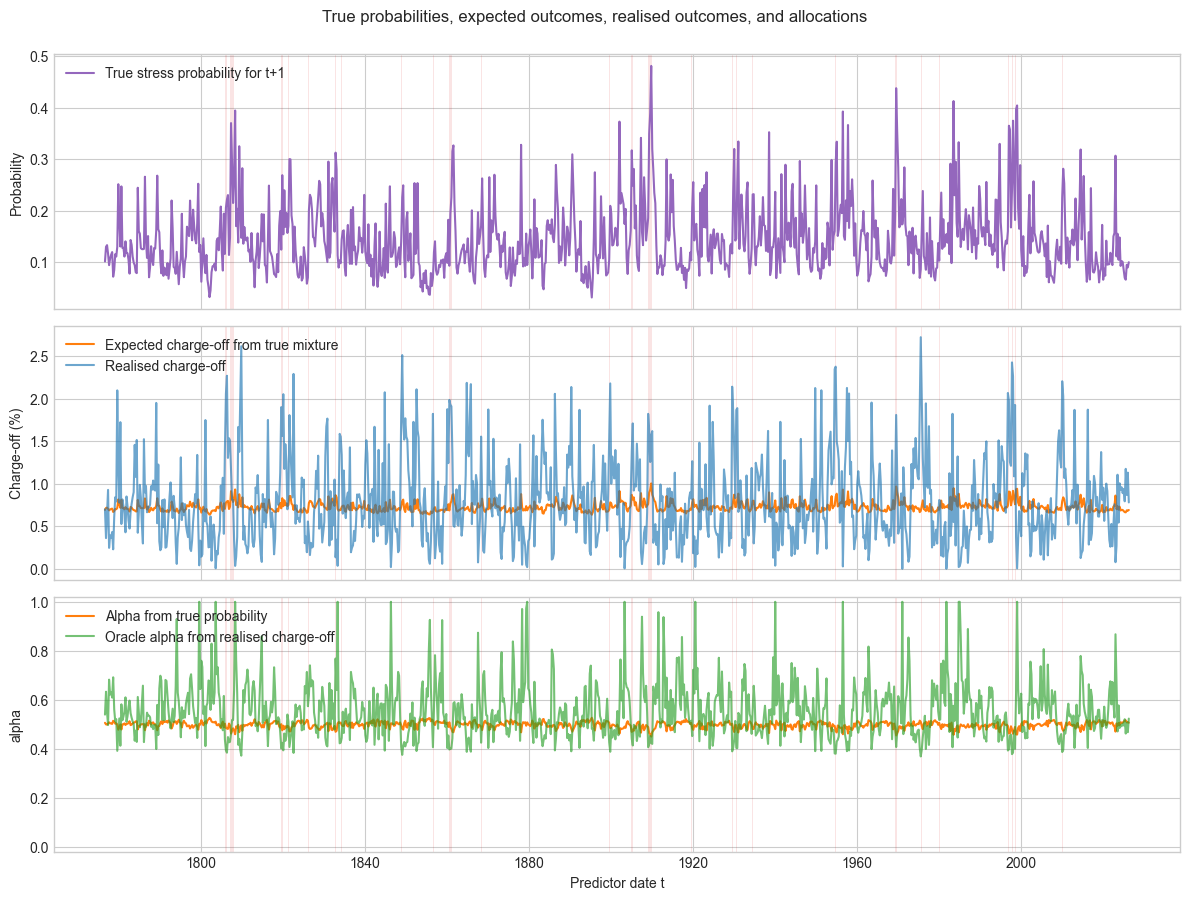

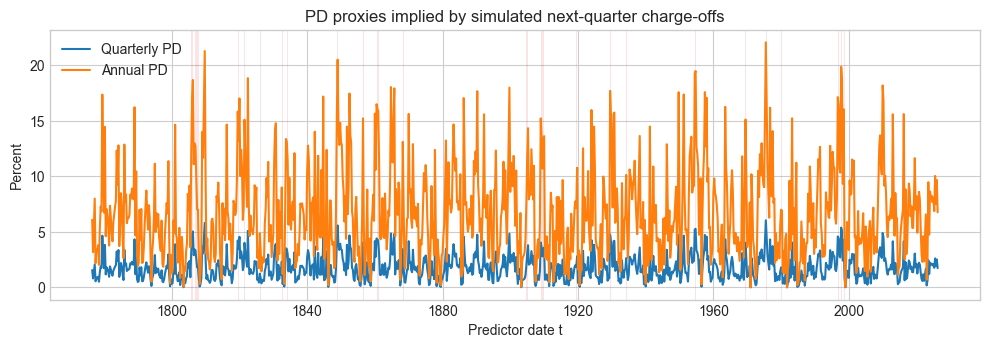

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(sim_df["DATE"], sim_df["sim_true_stress_probability"], color="tab:purple", label="True stress probability for t+1")
shade_stress_periods(axes[0], sim_df["DATE"], sim_df["sim_regime"])
axes[0].set_ylabel("Probability")
axes[0].legend(loc="upper left")

axes[1].plot(sim_df["DATE"], 100 * sim_df["sim_expected_charge_off_rate"], color="tab:orange", label="Expected charge-off from true mixture")
axes[1].plot(sim_df["DATE"], 100 * sim_df["sim_charge_off_rate"], color="tab:blue", alpha=0.65, label="Realised charge-off")
shade_stress_periods(axes[1], sim_df["DATE"], sim_df["sim_regime"])
axes[1].set_ylabel("Charge-off (%)")
axes[1].legend(loc="upper left")

axes[2].plot(sim_df["DATE"], sim_df["sim_alpha_from_true_probability"], color="tab:orange", label="Alpha from true probability")
axes[2].plot(sim_df["DATE"], sim_df["sim_oracle_alpha"], color="tab:green", alpha=0.65, label="Oracle alpha from realised charge-off")
shade_stress_periods(axes[2], sim_df["DATE"], sim_df["sim_regime"])
axes[2].set_ylabel("alpha")
axes[2].set_xlabel("Predictor date t")
axes[2].set_ylim(-0.02, 1.02)
axes[2].legend(loc="upper left")

fig.suptitle("True probabilities, expected outcomes, realised outcomes, and allocations", y=0.995)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(sim_df["DATE"], 100 * sim_df["sim_quarterly_pd"], label="Quarterly PD")
ax.plot(sim_df["DATE"], 100 * sim_df["sim_annual_pd"], label="Annual PD")
shade_stress_periods(ax, sim_df["DATE"], sim_df["sim_regime"])
ax.set_title("PD proxies implied by simulated next-quarter charge-offs")
ax.set_ylabel("Percent")
ax.set_xlabel("Predictor date t")
ax.legend(loc="upper left")
plt.show()

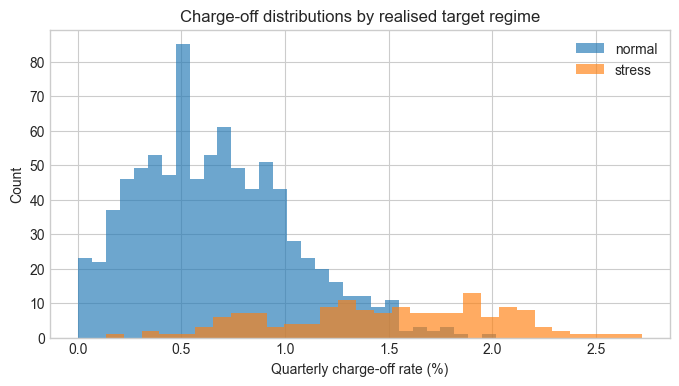

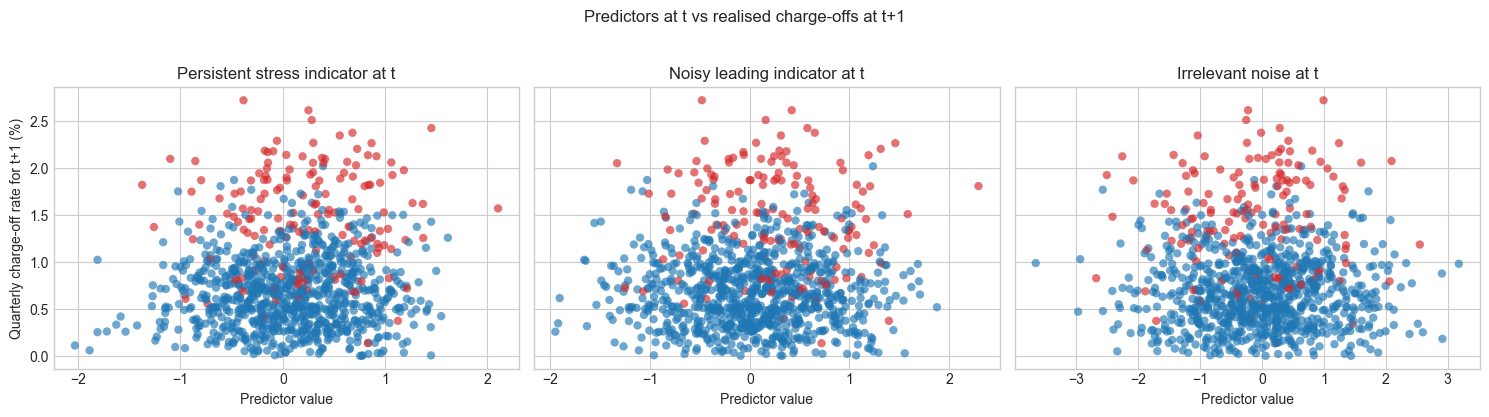

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, group in sim_df.groupby("sim_regime_label"):
    ax.hist(100 * group["sim_charge_off_rate"], bins=30, alpha=0.65, label=label)
ax.set_title("Charge-off distributions by realised target regime")
ax.set_xlabel("Quarterly charge-off rate (%)")
ax.set_ylabel("Count")
ax.legend()
plt.show()

scatter_specs = [
    ("sim_persistent_stress_indicator", "Persistent stress indicator at t"),
    ("sim_noisy_leading_indicator", "Noisy leading indicator at t"),
    ("sim_irrelevant_noise", "Irrelevant noise at t"),
]

fig, axes = plt.subplots(1, len(scatter_specs), figsize=(15, 4), sharey=True)
colors = np.where(sim_df["sim_regime"].eq(1), "tab:red", "tab:blue")
for ax, (col, title) in zip(axes, scatter_specs):
    ax.scatter(sim_df[col], 100 * sim_df["sim_charge_off_rate"], c=colors, alpha=0.65, edgecolor="none")
    ax.set_title(title)
    ax.set_xlabel("Predictor value")
axes[0].set_ylabel("Quarterly charge-off rate for t+1 (%)")
fig.suptitle("Predictors at t vs realised charge-offs at t+1", y=1.03)
plt.tight_layout()
plt.show()

## 7. Diagnostics and oracle allocation preview

Diagnostics check that the simulated targets match the intended two-regime mixture and forecasting timing.

Core diagnostics:


realised_stress_proportion          0.149000
normal_to_stress_probability        0.130435
stress_to_stress_probability        0.255034
chargeoff_min                       0.000022
chargeoff_max                       0.027213
chargeoff_lag1_autocorrelation      0.491909
realised_chargeoff_std              0.004946
expected_chargeoff_std              0.000550
oracle_alpha_std                    0.114411
alpha_from_true_probability_std     0.012741
non_positive_chargeoffs             0.000000
negative_chargeoff_resamples       65.000000
dtype: float64

Empirical target mu/sigma and negative-draw probability by regime:


,mu,sigma,negative_draw_probability
normal,0.0061,0.0042,0.073198
stress,0.0143,0.0067,0.016408


Simulated mean and standard deviation by realised target regime:


,count,mean,std
sim_regime_label,,,
normal,851,0.006652,0.003694
stress,149,0.014917,0.005314


Probability quantiles:


0.01    0.051726
0.05    0.069468
0.25    0.097611
0.50    0.130719
0.75    0.171419
0.95    0.281054
0.99    0.369820
Name: sim_true_stress_probability, dtype: float64

Probability bin proportions:


p_true_below_0.05      0.008
p_true_0.05_to_0.25    0.907
p_true_0.25_to_0.75    0.085
p_true_above_0.75      0.000
dtype: float64

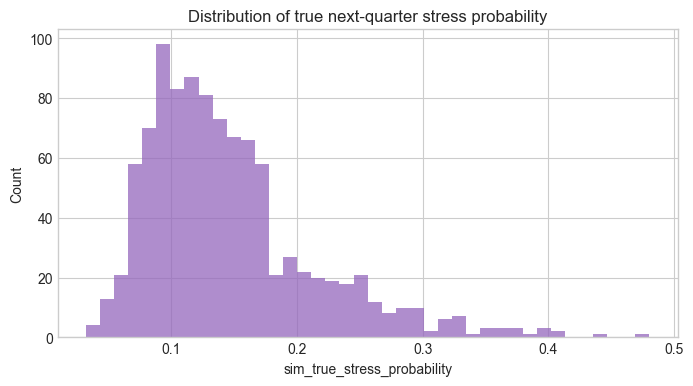

Transition counts: current regime at t -> realised target regime at t+1


sim_regime_label,normal,stress
sim_current_regime_label,,
normal,740,111
stress,111,38


Transition probabilities: current regime at t -> realised target regime at t+1


sim_regime_label,normal,stress
sim_current_regime_label,,
normal,0.869565,0.130435
stress,0.744966,0.255034


Charge-off quantiles:


0.00    0.000022
0.01    0.000315
0.05    0.001442
0.25    0.004296
0.50    0.007082
0.75    0.010333
0.95    0.018210
0.99    0.021854
1.00    0.027213
Name: sim_charge_off_rate, dtype: float64

Number of observations in each realised target regime:


sim_regime_label
normal    851
stress    149
Name: count, dtype: int64

,DATE,sim_target_DATE,sim_regime_label,sim_true_stress_probability,sim_expected_charge_off_rate,sim_charge_off_rate,sim_alpha_from_true_probability,sim_oracle_alpha
0,1776-06-30,1776-09-30,normal,0.101648,0.006934,0.007014,0.505903,0.539401
1,1776-09-30,1776-12-31,normal,0.130127,0.007167,0.003620,0.499214,0.632692
2,1776-12-31,1777-03-31,normal,0.133334,0.007193,0.006615,0.498520,0.548232
3,1777-03-31,1777-06-30,normal,0.116803,0.007058,0.009282,0.502218,0.496730
4,1777-06-30,1777-09-30,normal,0.094600,0.006876,0.002475,0.507728,0.682048


In [25]:
probability_bins = pd.Series({
    "p_true_below_0.05": (sim_df["sim_true_stress_probability"] < 0.05).mean(),
    "p_true_0.05_to_0.25": sim_df["sim_true_stress_probability"].between(0.05, 0.25, inclusive="left").mean(),
    "p_true_0.25_to_0.75": sim_df["sim_true_stress_probability"].between(0.25, 0.75, inclusive="left").mean(),
    "p_true_above_0.75": (sim_df["sim_true_stress_probability"] >= 0.75).mean(),
})

transition_counts = pd.crosstab(sim_df["sim_current_regime_label"], sim_df["sim_regime_label"])
transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)
normal_to_stress = transition_probs.loc["normal", "stress"] if "normal" in transition_probs.index and "stress" in transition_probs.columns else np.nan
stress_to_stress = transition_probs.loc["stress", "stress"] if "stress" in transition_probs.index and "stress" in transition_probs.columns else np.nan

diagnostics = {
    "realised_stress_proportion": sim_df["sim_regime"].mean(),
    "normal_to_stress_probability": normal_to_stress,
    "stress_to_stress_probability": stress_to_stress,
    "chargeoff_min": sim_df["sim_charge_off_rate"].min(),
    "chargeoff_max": sim_df["sim_charge_off_rate"].max(),
    "chargeoff_lag1_autocorrelation": sim_df["sim_charge_off_rate"].autocorr(lag=1),
    "realised_chargeoff_std": sim_df["sim_charge_off_rate"].std(),
    "expected_chargeoff_std": sim_df["sim_expected_charge_off_rate"].std(),
    "oracle_alpha_std": sim_df["sim_oracle_alpha"].std(),
    "alpha_from_true_probability_std": sim_df["sim_alpha_from_true_probability"].std(),
    "non_positive_chargeoffs": int((sim_df["sim_charge_off_rate"] <= 0).sum()),
    "negative_chargeoff_resamples": chargeoff_resample_count,
}

print("Core diagnostics:")
display(pd.Series(diagnostics))

print("Empirical target mu/sigma and negative-draw probability by regime:")
display(mixture_params_df)

print("Simulated mean and standard deviation by realised target regime:")
display(sim_df.groupby("sim_regime_label")["sim_charge_off_rate"].agg(["count", "mean", "std"]))

print("Probability quantiles:")
display(sim_df["sim_true_stress_probability"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).rename("sim_true_stress_probability"))

print("Probability bin proportions:")
display(probability_bins)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sim_df["sim_true_stress_probability"], bins=40, color="tab:purple", alpha=0.75)
ax.set_title("Distribution of true next-quarter stress probability")
ax.set_xlabel("sim_true_stress_probability")
ax.set_ylabel("Count")
plt.show()

print("Transition counts: current regime at t -> realised target regime at t+1")
display(transition_counts)

print("Transition probabilities: current regime at t -> realised target regime at t+1")
display(transition_probs)

print("Charge-off quantiles:")
display(sim_df["sim_charge_off_rate"].quantile([0.0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]).rename("sim_charge_off_rate"))

print("Number of observations in each realised target regime:")
display(sim_df["sim_regime_label"].value_counts())

display(sim_df[["DATE", "sim_target_DATE", "sim_regime_label", "sim_true_stress_probability", "sim_expected_charge_off_rate", "sim_charge_off_rate", "sim_alpha_from_true_probability", "sim_oracle_alpha"]].head())

## 8. Save output

In [26]:
output_dir = REPO_ROOT / "models" / "simulation" / "data"
output_dir.mkdir(parents=True, exist_ok=True)

# Each row is a forecasting example: predictors at DATE=t, targets at sim_target_DATE=t+1.
simulation_output_cols = [
    "DATE",
    "sim_target_DATE",
    "sim_current_regime",
    "sim_current_regime_label",
    "sim_persistent_stress_indicator",
    "sim_noisy_leading_indicator",
    "sim_irrelevant_noise",
    "sim_true_stress_probability",
    "sim_regime",
    "sim_regime_label",
    "sim_expected_charge_off_rate",
    "sim_charge_off_rate",
    "sim_quarterly_pd",
    "sim_annual_pd",
    "sim_alpha_from_true_probability",
    "sim_oracle_alpha",
]

sim_output_df = sim_df[simulation_output_cols].copy()

output_csv = output_dir / "simulated_variables.csv"
sim_output_df.to_csv(output_csv, index=False)

print(f"Saved simulated forecasting dataframe to: {output_csv.relative_to(REPO_ROOT)}")
display(sim_output_df.head())

Saved simulated forecasting dataframe to: models/simulation/data/simulated_variables.csv


,DATE,sim_target_DATE,sim_current_regime,sim_current_regime_label,sim_persistent_stress_indicator,sim_noisy_leading_indicator,sim_irrelevant_noise,sim_true_stress_probability,sim_regime,sim_regime_label,sim_expected_charge_off_rate,sim_charge_off_rate,sim_quarterly_pd,sim_annual_pd,sim_alpha_from_true_probability,sim_oracle_alpha
0,1776-06-30,1776-09-30,0,normal,-0.020749,-0.443797,0.304717,0.101648,0,normal,0.006934,0.007014,0.015587,0.060904,0.505903,0.539401
1,1776-09-30,1776-12-31,0,normal,0.205269,0.063377,-1.039984,0.130127,0,normal,0.007167,0.003620,0.008045,0.031795,0.499214,0.632692
2,1776-12-31,1777-03-31,0,normal,0.398743,-0.105282,0.750451,0.133334,0,normal,0.007193,0.006615,0.014700,0.057518,0.498520,0.548232
3,1777-03-31,1777-06-30,0,normal,0.451590,-0.605411,0.940565,0.116803,0,normal,0.007058,0.009282,0.020626,0.079987,0.502218,0.496730
4,1777-06-30,1777-09-30,0,normal,0.186011,-0.937254,-1.951035,0.094600,0,normal,0.006876,0.002475,0.005501,0.021822,0.507728,0.682048
